In [18]:
import pandas as pd
import os

# 统计每一种设计总数下，按照overall confidence排序，top10中不同序列的个数
with open('PDB.list') as f:
    pdbs = [line.strip() for line in f.readlines()]

model = 'ligandmpnn_v_32_020_25'
df_total = pd.DataFrame()
# os.makedirs('seq_stats', exist_ok=True)

df_list = []
for pdb in pdbs:
    records = []
    stats = []
    for numbers in [100, 500, 1000, 2000, 5000, 10000]:
        src_file = f'{numbers}-0.1T/{model}/seqs/{pdb}.fa'
        des_dir = f'{numbers}-0.1T/{model}/seq_stats'
        os.makedirs(des_dir, exist_ok=True)

        with open(src_file, 'r') as f:
            lines = f.readlines()[2:]  # skip first two lines
        overall_confidence = None
        for line in lines:
            line = line.strip()
            if not line:
                continue
            if line.startswith('>'):
                parts = line[1:].split(',')
                overall_confidence = float(parts[4].split('=')[1])
            else:
                records.append(
                    {
                        'PDB': pdb,
                        'Design_Numbers': numbers,
                        'Sequence': line,
                        'Overall_Confidence': overall_confidence,
                    }
                )
   
        df_pdb = pd.DataFrame(records)
        # 按照overall confidence排序，统计top10/20/50/100的不同序列个数以及对应的序列
        for top_n in [10, 20, 50, 100]:
            df_top_n = df_pdb.sort_values(by='Overall_Confidence', ascending=False).head(top_n)
            seq_counts = df_top_n['Sequence'].value_counts()
            seq_conf = df_top_n.groupby('Sequence')['Overall_Confidence'].apply(list)
            seqs_with_counts = [
            f"{seq}({count};{','.join(f'{c:.4f}' for c in seq_conf[seq])})"
            for seq, count in seq_counts.items()
            ]
            stats.append(
            {
                'numbers': numbers,
                'Top_N': top_n,
                'Unique_Sequences': seq_counts.size,
                'Sequences_with_Counts': ';'.join(seqs_with_counts),
            }
            )
        os.makedirs('seq_stats_summary', exist_ok=True)
        pd.DataFrame(stats).to_csv(f'seq_stats_summary/{pdb}_top_seq_stats.csv', index=False)
        if not records:
            continue
# # 将所有的df合并到df_total中
# df_total = pd.concat(df_list, ignore_index=True)


In [19]:
from matplotlib.ticker import MaxNLocator

# 读取seq_stats_summary中的文件，统计每个pdb在不同设计总数下，top10/20/50/100的不同序列个数，分别为每一个pdb绘制曲线，横坐标为设计总数，纵坐标为不同序列个数，每一张图中包含top10/20/50/100四条曲线
for pdb in pdbs:
    stats_file = f'seq_stats_summary/{pdb}_top_seq_stats.csv'
    if not os.path.exists(stats_file):
        continue
    df_stats = pd.read_csv(stats_file)
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))
    for top_n in [10, 20, 50, 100]:
        df_top_n = df_stats[df_stats['Top_N'] == top_n]
        plt.plot(
            df_top_n['numbers'],
            df_top_n['Unique_Sequences'],
            marker='o',
            label=f'Top {top_n}',
        )
    plt.xlabel('Design Numbers')
    plt.ylabel('Unique Sequences Count')
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.title(f'Unique Sequences Count vs Design Numbers for {pdb}')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'seq_stats_summary/{pdb}_unique_sequences_plot.png')
    plt.close()

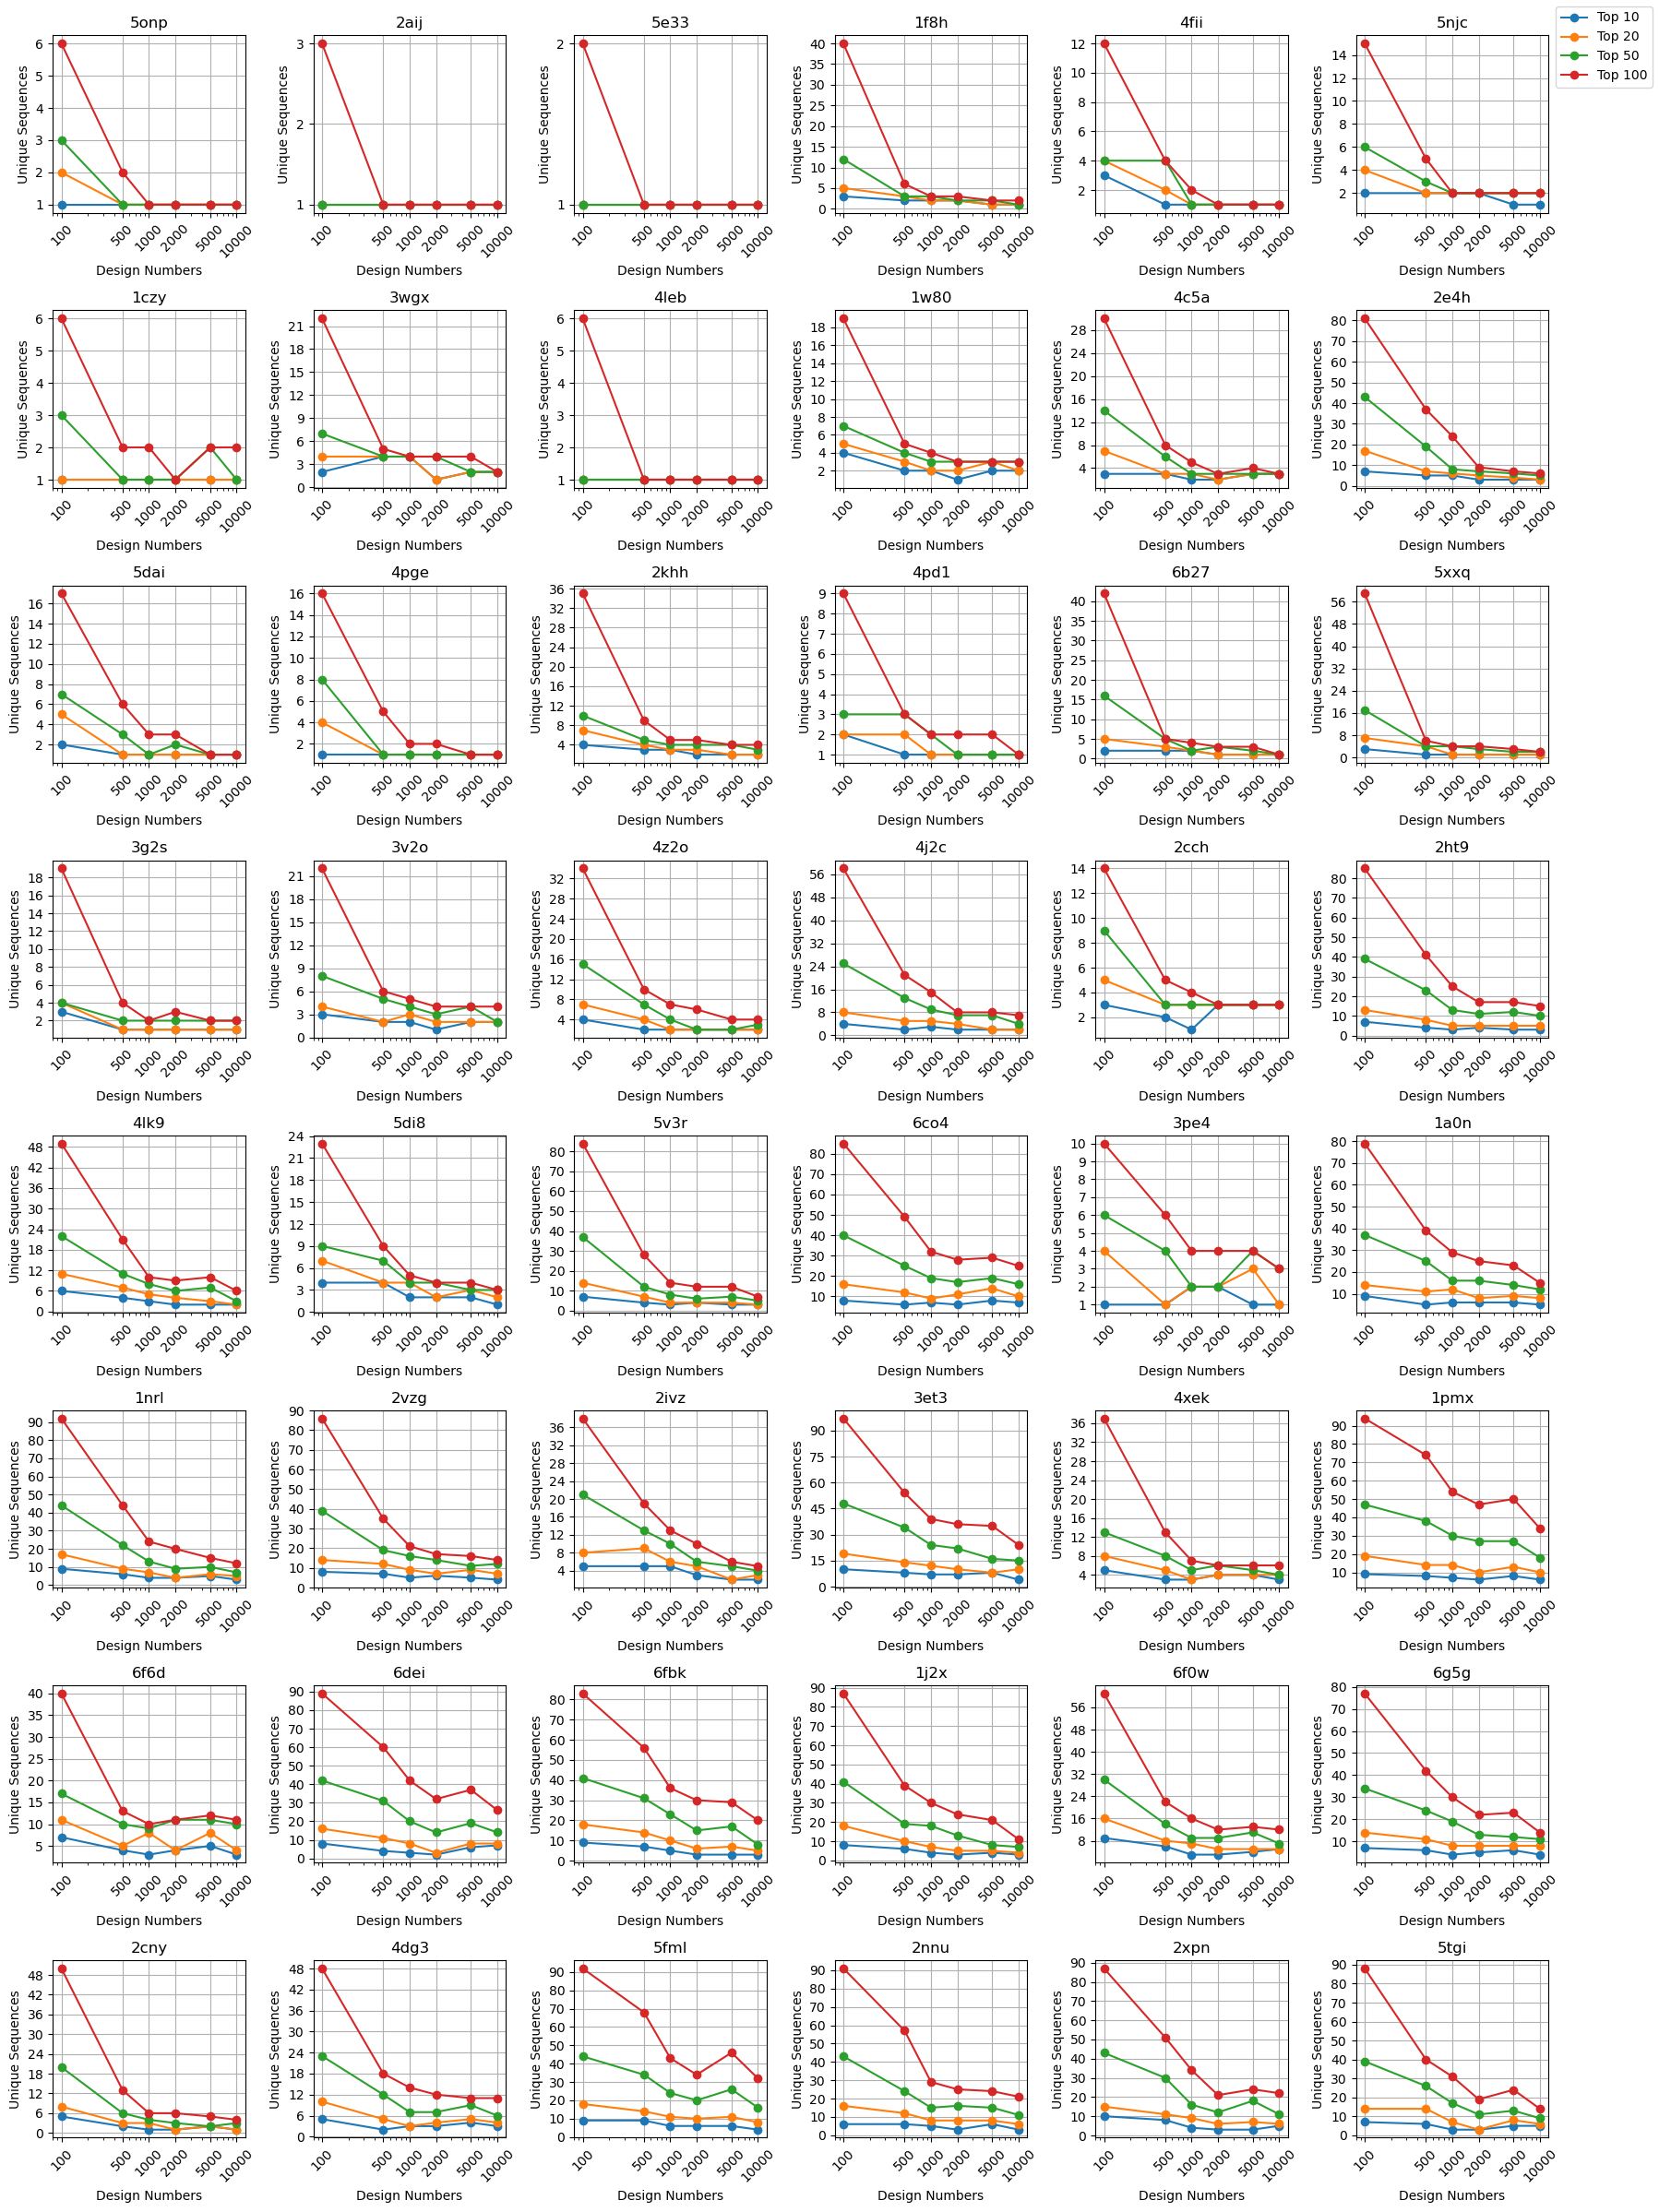

In [5]:
import matplotlib.pyplot as plt
import os
import pandas as pd
from matplotlib.ticker import MaxNLocator

# 在一张主图中为每个 pdb 绘制子图（8 行 6 列）
fig, axes = plt.subplots(8, 6, figsize=(18, 24))
axes = axes.flat

with open('PDB.list') as f:
    pdbs = [line.strip() for line in f.readlines()]

for idx, pdb in enumerate(pdbs):
    if idx >= len(axes):
        break
    stats_file = f'seq_stats_summary/{pdb}_top_seq_stats.csv'
    if not os.path.exists(stats_file):
        axes[idx].axis('off')
        continue

    df_stats = pd.read_csv(stats_file)
    ax = axes[idx]
    for top_n in [10, 20, 50, 100]:
        df_top_n = df_stats[df_stats['Top_N'] == top_n]
        ax.plot(df_top_n['numbers'], df_top_n['Unique_Sequences'], marker='o', label=f'Top {top_n}')

    ax.set_title(pdb)
    ax.set_xlabel('Design Numbers')
    ax.semilogx()
    ax.set_xticks([100, 500, 1000, 2000, 5000, 10000])
    ax.set_xticklabels([100, 500, 1000, 2000, 5000, 10000], rotation=45)
    ax.set_fontsize=11
    ax.set_ylabel('Unique Sequences')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True)

# 关闭多余的子图轴
for ax in axes[len(pdbs):]:
    ax.axis('off')

# 统一放置图例
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
plt.tight_layout(rect=[0, 0, 0.95, 1])
# plt.savefig('seq_stats_summary/all_pdbs_unique_sequences_plot.png')
# plt.close(fig)
plt.show()

In [10]:
# 绘制两张图：每张图 4 行 6 列子图，分别对应前 24 个和后 24 个 PDB
import matplotlib.pyplot as plt
import os
import pandas as pd
from matplotlib.ticker import MaxNLocator

def plot_batch(pdb_batch, outfile):
    fig_batch, axs_batch = plt.subplots(4, 6, figsize=(18, 12))
    axs_batch = axs_batch.ravel()
    legend_handles, legend_labels = None, None

    for i, pdb in enumerate(pdb_batch):
        ax = axs_batch[i]
        stats_file = f'seq_stats_summary/{pdb}_top_seq_stats.csv'
        if not os.path.exists(stats_file):
            ax.axis('off')
            continue

        df_stats = pd.read_csv(stats_file)
        for top_n in [10, 20, 50, 100]:
            df_top_n = df_stats[df_stats['Top_N'] == top_n]
            ax.plot(df_top_n['numbers'], df_top_n['Unique_Sequences'], marker='o', label=f'Top {top_n}')
        ax.set_title(pdb)
        ax.set_xlabel('Design Numbers')
        ax.set_ylabel('Unique Sequences')
        ax.semilogx()
        ax.set_xticks([100, 500, 1000, 2000, 5000, 10000])
        ax.set_xticklabels([100, 500, 1000, 2000, 5000, 10000], rotation=45)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        # ax.grid(True)
        # 设置横坐标为2000的位置增加一条垂直线
        ax.axvline(x=2000, color='r', linestyle='--', linewidth=1.0)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    for ax in axs_batch[len(pdb_batch):]:
        ax.axis('off')

    if legend_handles:
        fig_batch.legend(legend_handles, legend_labels, loc='upper right')
    plt.tight_layout(rect=[0, 0, 0.95, 1])
    plt.savefig(outfile)
    plt.close(fig_batch)

with open('PDB.list') as f:
    pdbs = [line.strip() for line in f.readlines()]

plot_batch(pdbs[:24], 'seq_stats_summary/pdbs_1_24_unique_sequences.png')
plot_batch(pdbs[24:48], 'seq_stats_summary/pdbs_25_48_unique_sequences.png')